# Clinical Data Analysis: TCGA-LIHC (Liver Hepatocellular Carcinoma)
This notebook performs end-to-end data cleaning, deduplication, exploratory data analysis (EDA), and clinical visualization for `clinical_2/`.

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Visualization aesthetics
sns.set_theme(style='whitegrid')
plt.rcParams.update({
    'font.sans-serif': 'Segoe UI',
    'font.family': 'sans-serif',
    'figure.titlesize': 15,
    'axes.titlesize': 12,
    'axes.labelsize': 10
})

# 1. Load dataset
na_tokens = ["'--", '--', 'not reported', 'Not Reported', 'unknown', 'Unknown']
df_raw = pd.read_csv('clinical_2/clinical.tsv', sep='\t', low_memory=False, na_values=na_tokens)
print(f'Total records loaded: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns')

Total records loaded: 2845 rows, 202 columns


In [3]:
# 2. Patient-level aggregation & deduplication
def get_first_valid(df, col):
    if col not in df.columns:
        return pd.Series(dtype=object)
    sub = df[~df[col].isna()]
    return sub.groupby('cases.case_id')[col].first()

cases = df_raw.drop_duplicates(subset=['cases.case_id'])[['cases.case_id', 'cases.submitter_id', 'project.project_id']].copy()
cases.set_index('cases.case_id', inplace=True)

# Extract patient demographic & diagnostic metrics
cases['Age'] = pd.to_numeric(get_first_valid(df_raw, 'demographic.age_at_index'), errors='coerce')
cases['Sex'] = get_first_valid(df_raw, 'demographic.sex_at_birth').str.capitalize()
cases['Vital_Status'] = get_first_valid(df_raw, 'demographic.vital_status').fillna('Unknown')
cases['Race'] = get_first_valid(df_raw, 'demographic.race').str.title()
cases['Primary_Diagnosis'] = get_first_valid(df_raw, 'diagnoses.primary_diagnosis')
cases['Tumor_Grade'] = get_first_valid(df_raw, 'diagnoses.tumor_grade')
cases['AJCC_Stage'] = get_first_valid(df_raw, 'diagnoses.ajcc_pathologic_stage')
cases['Ishak_Fibrosis'] = get_first_valid(df_raw, 'diagnoses.ishak_fibrosis_score')

# Survival and follow-up duration (in months)
days_death = pd.to_numeric(get_first_valid(df_raw, 'demographic.days_to_death'), errors='coerce')
days_follow = pd.to_numeric(get_first_valid(df_raw, 'diagnoses.days_to_last_follow_up'), errors='coerce')
cases['Survival_Months'] = days_death.fillna(days_follow) / 30.44

def simplify_stage(val):
    if not isinstance(val, str):
        return 'Unknown'
    val = val.strip()
    if val.startswith('Stage IV'): return 'Stage IV'
    elif val.startswith('Stage III'): return 'Stage III'
    elif val.startswith('Stage II'): return 'Stage II'
    elif val.startswith('Stage I') and not val.startswith('Stage 0'): return 'Stage I'
    elif val == 'Stage 0': return 'Stage 0'
    return 'Other / Unknown'

cases['Stage_Grouped'] = cases['AJCC_Stage'].apply(simplify_stage)

print(f'Cohort size: {len(cases)} unique patients')
cases.head()

Cohort size: 377 unique patients


,cases.submitter_id,project.project_id,Age,Sex,Vital_Status,Race,Primary_Diagnosis,Tumor_Grade,AJCC_Stage,Ishak_Fibrosis,Survival_Months,Stage_Grouped
cases.case_id,,,,,,,,,,,,
0004d251-3f70-4395-b175-c94c2f5b1b81,TCGA-DD-AAVP,TCGA-LIHC,48.0,Male,Alive,Asian,"Hepatocellular carcinoma, NOS",G1,Stage I,6 - Established Cirrhosis,NaN,Stage I
001887aa-36d0-463f-8bca-dec7043b4f2e,TCGA-DD-A4NP,TCGA-LIHC,32.0,Male,Alive,White,"Hepatocellular carcinoma, NOS",G3,Stage I,0 - No Fibrosis,NaN,Stage I
00f209c3-041a-4c6e-8b0f-6383eb3c85fc,TCGA-BC-4073,TCGA-LIHC,73.0,Male,Alive,White,"Hepatocellular carcinoma, NOS",G3,Stage IIIA,NaN,NaN,Stage III
010d5817-9a3f-4a06-8643-653116c044ff,TCGA-MI-A75E,TCGA-LIHC,61.0,Male,Alive,White,"Hepatocellular carcinoma, NOS",G2,Stage IIIC,"1,2 - Portal Fibrosis",NaN,Stage III
01cc571c-a47c-4548-9c14-5e51c79b095b,TCGA-G3-A7M8,TCGA-LIHC,31.0,Male,Alive,Asian,"Hepatocellular carcinoma, NOS",G1,Stage I,6 - Established Cirrhosis,NaN,Stage I


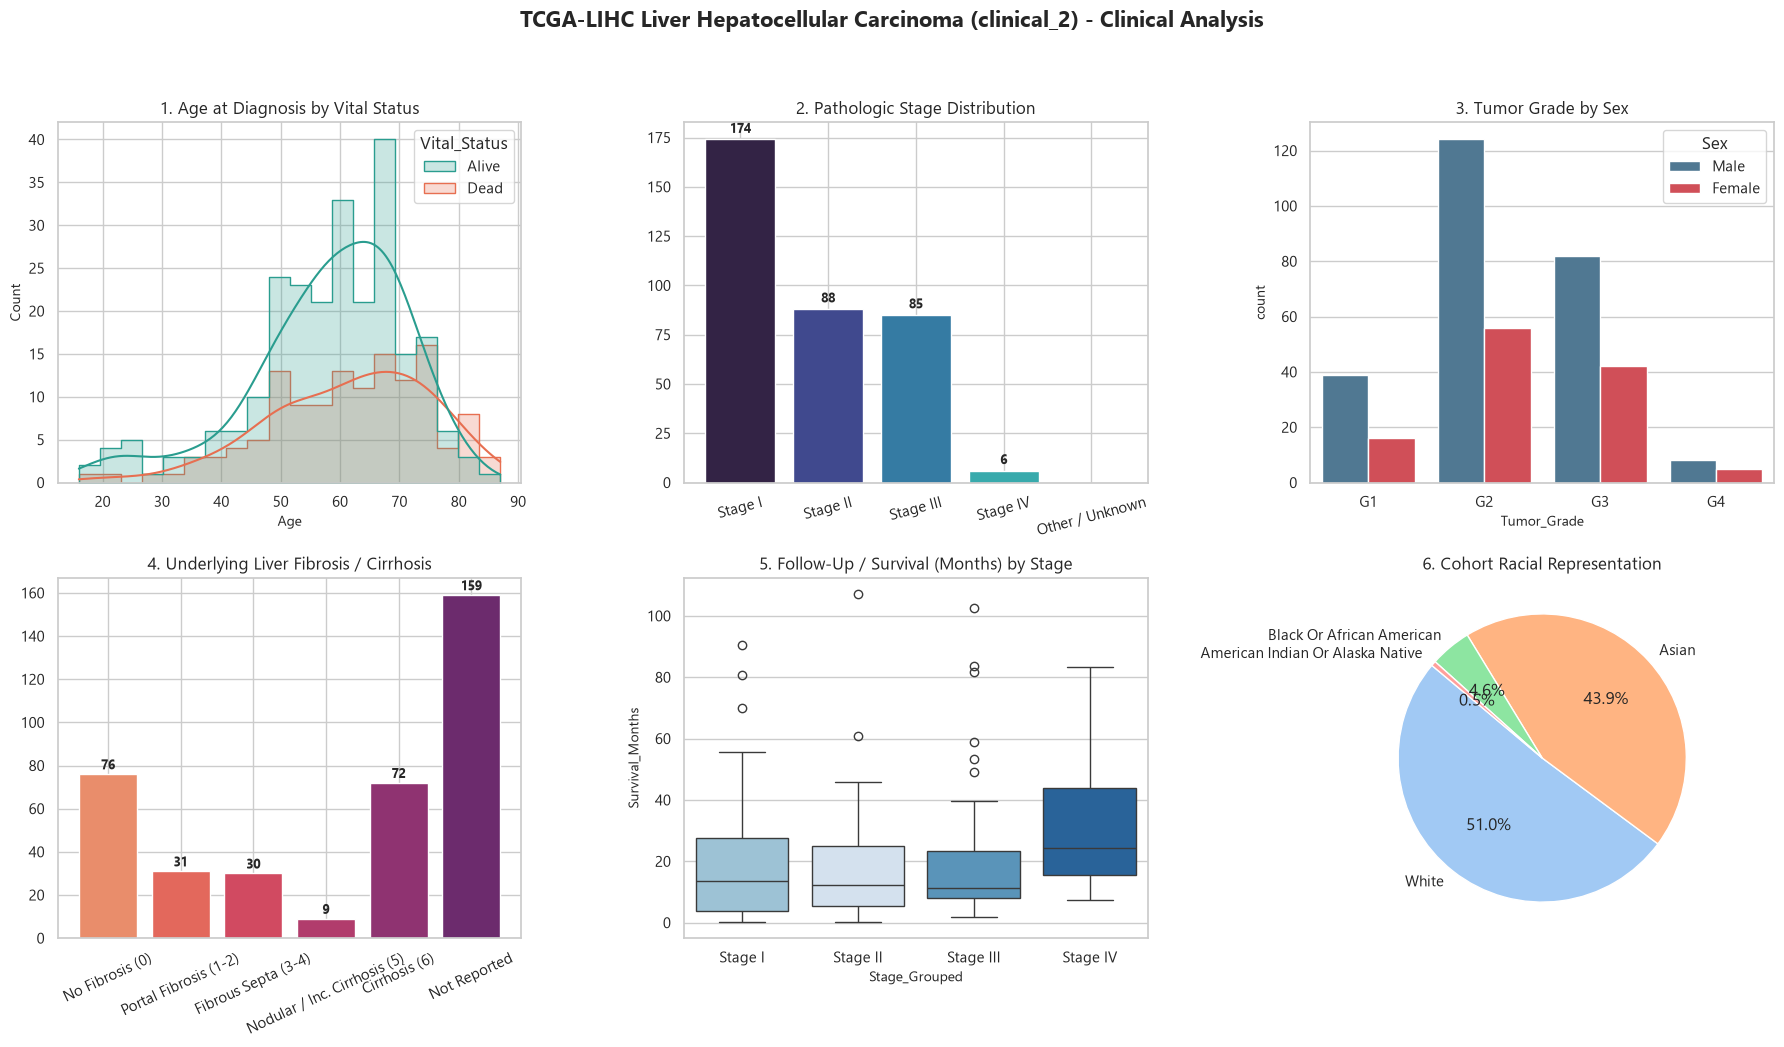

In [4]:
# 3. Exploratory Visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('TCGA-LIHC Liver Hepatocellular Carcinoma (clinical_2) - Clinical Analysis', fontsize=16, fontweight='bold', y=0.98)

# 1. Age by Vital Status
sns.histplot(data=cases, x='Age', hue='Vital_Status', kde=True, bins=20, element='step', palette={'Alive': '#2a9d8f', 'Dead': '#e76f51'}, ax=axes[0, 0])
axes[0, 0].set_title('1. Age at Diagnosis by Vital Status')

# 2. AJCC Pathologic Stage Breakdown
stage_order = ['Stage I', 'Stage II', 'Stage III', 'Stage IV', 'Other / Unknown']
stage_counts = cases['Stage_Grouped'].value_counts().reindex(stage_order).fillna(0)
bars2 = axes[0, 1].bar(stage_counts.index, stage_counts.values, color=sns.color_palette('mako', len(stage_counts)))
axes[0, 1].set_title('2. Pathologic Stage Distribution')
axes[0, 1].tick_params(axis='x', rotation=15)
for bar in bars2:
    yval = bar.get_height()
    if yval > 0:
        axes[0, 1].text(bar.get_x() + bar.get_width()/2.0, yval + 2, f'{int(yval)}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# 3. Tumor Grade by Sex
grade_order = ['G1', 'G2', 'G3', 'G4']
sns.countplot(data=cases[cases['Tumor_Grade'].isin(grade_order)], x='Tumor_Grade', hue='Sex', order=grade_order, palette={'Male': '#457b9d', 'Female': '#e63946'}, ax=axes[0, 2])
axes[0, 2].set_title('3. Tumor Grade by Sex')

# 4. Liver Fibrosis (Ishak Score)
def simplify_fibrosis(val):
    if not isinstance(val, str): return 'Not Reported'
    if '0' in val: return 'No Fibrosis (0)'
    elif '1' in val or '2' in val: return 'Portal Fibrosis (1-2)'
    elif '3' in val or '4' in val: return 'Fibrous Septa (3-4)'
    elif '5' in val: return 'Nodular / Inc. Cirrhosis (5)'
    elif '6' in val: return 'Cirrhosis (6)'
    return 'Not Reported'
cases['Fibrosis_Category'] = cases['Ishak_Fibrosis'].apply(simplify_fibrosis)
fib_order = ['No Fibrosis (0)', 'Portal Fibrosis (1-2)', 'Fibrous Septa (3-4)', 'Nodular / Inc. Cirrhosis (5)', 'Cirrhosis (6)', 'Not Reported']
fib_counts = cases['Fibrosis_Category'].value_counts().reindex(fib_order).fillna(0)
bars4 = axes[1, 0].bar(fib_counts.index, fib_counts.values, color=sns.color_palette('flare', len(fib_counts)))
axes[1, 0].set_title('4. Underlying Liver Fibrosis / Cirrhosis')
axes[1, 0].tick_params(axis='x', rotation=25)
for bar in bars4:
    yval = bar.get_height()
    if yval > 0:
        axes[1, 0].text(bar.get_x() + bar.get_width()/2.0, yval + 1, f'{int(yval)}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# 5. Survival Duration by Stage
valid_surv = cases[cases['Survival_Months'].notna() & cases['Stage_Grouped'].isin(['Stage I', 'Stage II', 'Stage III', 'Stage IV'])]
sns.boxplot(data=valid_surv, x='Stage_Grouped', y='Survival_Months', hue='Stage_Grouped', legend=False, order=['Stage I', 'Stage II', 'Stage III', 'Stage IV'], palette='Blues', ax=axes[1, 1])
axes[1, 1].set_title('5. Follow-Up / Survival (Months) by Stage')

# 6. Racial Distribution
race_counts = cases['Race'].value_counts().head(5)
axes[1, 2].pie(race_counts.values, labels=race_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
axes[1, 2].set_title('6. Cohort Racial Representation')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()